In [1]:


from src.utils import utils
from src.data.data_loading import load_articles, load_links, load_unfinished_paths, load_finished_paths, load_categories

# Imports
import pandas as pd
import numpy as np
import networkx as nx

# ----------- Statistics -------------------- #
from scipy.stats import spearmanr
from scipy.stats import linregress
# Tests
from scipy.stats import chi2_contingency

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
from adjustText import adjust_text

Load necessary files for analysis

In [2]:
# Load the unfinished paths dataFrame
df_unfinished = load_unfinished_paths()

# Load the finished paths dataFrame
df_finished = load_finished_paths()

# Load the categories dataframe
df_categories = load_categories()

# Load links
df_links = load_links()

# Load articles
df_articles = load_articles()

# Creating a dictionary for categories, to clasify the subcategories into their respective target categories
n = len(df_categories)
class_categories = {}
for i in range(n):
    a = df_categories.loc[i]['category1']
    b = df_categories.loc[i]['category2']
    if a not in class_categories:
        class_categories[a] = []
    if b not in class_categories[a]:
        class_categories[a] = class_categories[a] + [b]

## Main and secondary categories ordered by difficulty, considering unfinished games in that category

### Ratio of unfinished games

Count number of total games and unfinished games per category

In [3]:
# UNFINISHED PATHS
# Select 'category1' and 'category 2' 
target_categories = df_unfinished['category1']
S_categories = df_unfinished['category2']

# Remove rows with NaN values
target_categories_unfinished = target_categories.dropna()
S_categories_unfinished = S_categories.dropna()

# Count number of known categories for all articles in unfinished paths
target_categories_unfinished = target_categories_unfinished.value_counts()
S_categories_unfinished = S_categories_unfinished.value_counts()


# FINISHED PATHS
# Select 'category1' and 'category 2' 
target_categories = df_finished['category1']
S_categories = df_finished['category2']

# Remove rows with NaN values
target_categories_finished = target_categories.dropna()
S_categories_finished = S_categories.dropna()

# Count number of known categories for all articles in unfinished paths
target_categories_finished = target_categories_finished.value_counts()
S_categories_finished = S_categories_finished.value_counts()


# Total number of categories for all articles
target_categories_total_count = target_categories_finished + target_categories_unfinished
S_categories_total_count = S_categories_finished + S_categories_unfinished

Ratio of unfinished paths

In [4]:
target_categories_Runf = target_categories_unfinished/target_categories_total_count
S_categories_Runf = S_categories_unfinished/S_categories_total_count

### Average difficulty

Now we will calculate the average difficulty of each category (target and secondary), and multiply it by the ratio of unfinished paths. The idea is that we want to weigh in the fact that if a category has a lot of unifinished paths, it generally means that it was difficult enough to not finish. Thus the higher the ratio, the higher the consideration for an average difficulty .

In [5]:
# Drop entries (games) with no 'rating'
df_finished_categories = df_finished.dropna(subset=['rating']).reset_index(drop=True)

# Computing average 'rating' for every category
df_Tdifficulty = df_finished [['rating','category1']]
df_Sdifficulty = df_finished[['rating', 'category2']]

Tdifficulty_target = df_Tdifficulty.groupby('category1').value_counts().unstack()
Sdifficulty_target = df_Sdifficulty.groupby('category2').value_counts().unstack()

Tweighted_sum = (Tdifficulty_target * Tdifficulty_target.columns).sum(axis=1)
Sweighted_sum = (Sdifficulty_target * Sdifficulty_target.columns).sum(axis=1)

Ttotal_count = Tdifficulty_target.sum(axis=1)
Taverage_rating = Tweighted_sum / Ttotal_count

Stotal_count = Sdifficulty_target.sum(axis=1)
Saverage_rating = Sweighted_sum / Stotal_count

### Weighed difficulty

Calculating the difficulty

In [6]:
T_weighed_rating = Taverage_rating * target_categories_Runf
S_weighed_rating = Saverage_rating * S_categories_Runf

The results

C:\Users\Marc\AppData\Local\Temp\ipykernel_12792\582932687.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab20', len(sorted_categories))


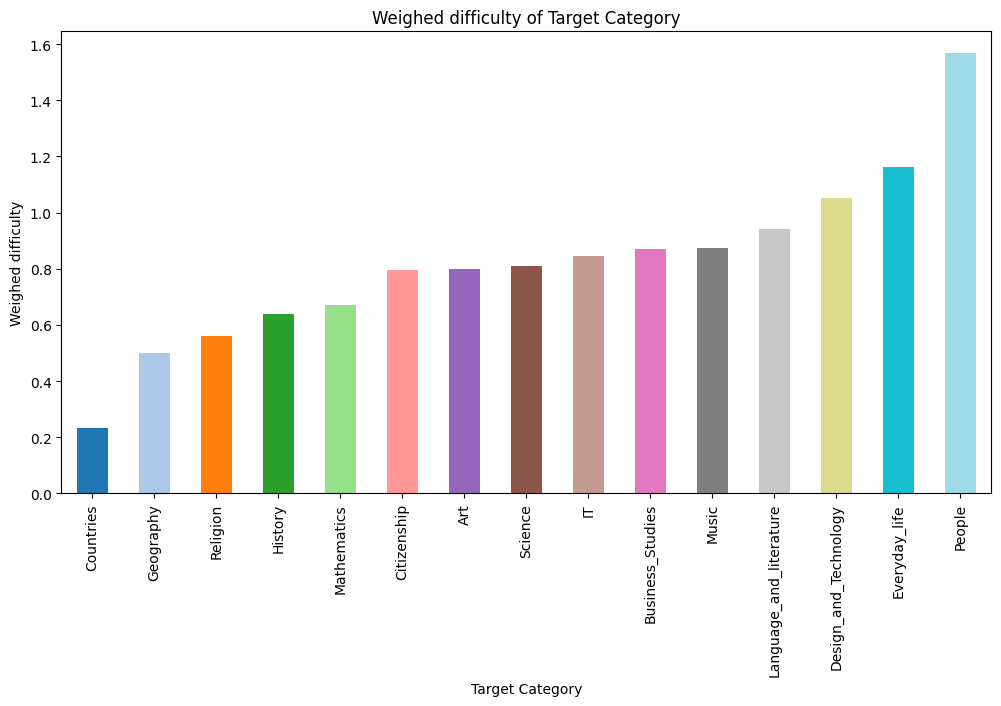

In [7]:
# Sorting before creating the color map
sorted_T_weighed_rating = T_weighed_rating.sort_values()

# Creating a color map for each category
sorted_categories = sorted_T_weighed_rating.index
colormap = cm.get_cmap('tab20', len(sorted_categories))
colors = {category: colormap(i) for i, category in enumerate(sorted_categories)}

target_rating_rank = T_weighed_rating.rank(ascending=False).sort_values()

# Bar plot for target categories
sorted_T_weighed_rating.plot(kind='bar', figsize=(12, 6), color = [colors[category] for category in sorted_categories])
plt.title("Weighed difficulty of Target Category")
plt.xlabel("Target Category")
plt.ylabel("Weighed difficulty")
plt.show()

In [8]:
def subcat_to_cat(subcat):
    for cat1, cat2 in class_categories.items():
        if subcat in cat2:
            return cat1


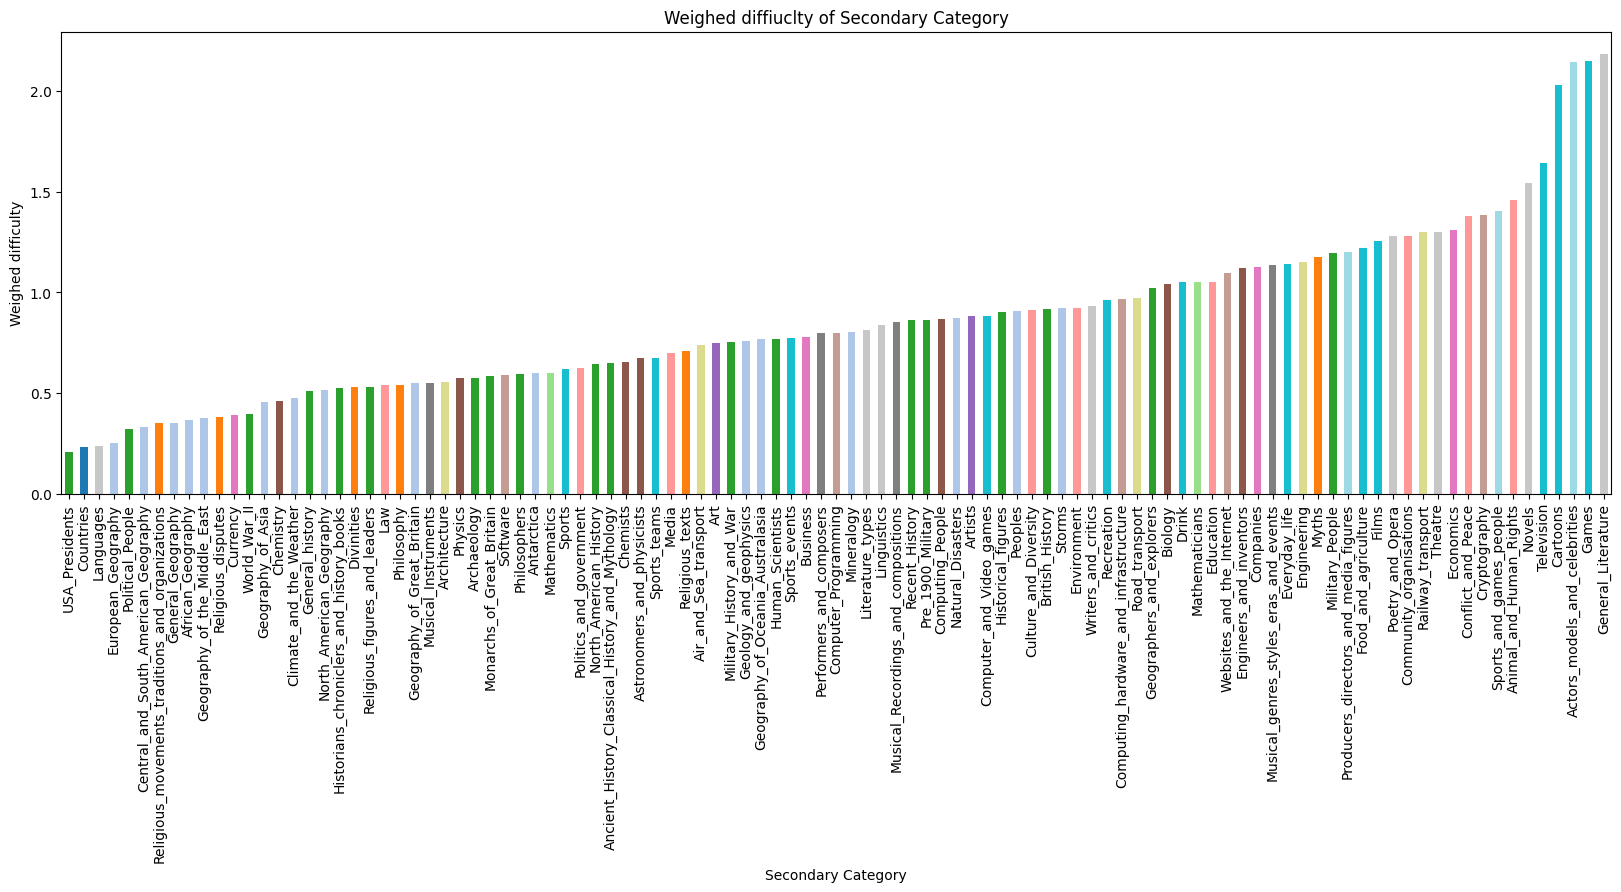

In [9]:
# Sorting the values first
sorted_S_weighed_rating = S_weighed_rating.sort_values()

# Creating a color map for the subcategories
sorted_subcategories = sorted_S_weighed_rating.index

subcategory_to_category = {
    subcat : subcat_to_cat(subcat) for subcat in sorted_subcategories   
}

subcategory_colors = {subcat: colors[category] for subcat, category in subcategory_to_category.items()}


S_rating_rank = S_weighed_rating.rank(ascending=False).sort_values()

# Bar plot for target categories
sorted_S_weighed_rating.plot(kind='bar', figsize=(20, 6), color=[subcategory_colors[subcat] for subcat in sorted_subcategories])
plt.title("Weighed diffiuclty of Secondary Category")
plt.xlabel("Secondary Category")
plt.ylabel("Weighed difficulty")
plt.show()

## Studying the relationship between weighed average difficulty and time spent on the game

### Target categories

Defining the variables

In [10]:
# Time taken in a game, and their respective category 
df_timecatraw = df_finished [['durationInSec','category1']]

IndexT = df_timecatraw['category1'].value_counts().index.astype(str)
n1 = len(IndexT)
n2 = len(df_timecatraw)
timecat = {IndexT[i]: [0] for i in range(n1)}
df_timecat = pd.DataFrame(timecat)
df_count = pd.DataFrame(timecat)

for i in range(n2):
    for j in range(n1):
        a = df_timecatraw.loc[i]['category1']
        if a == IndexT[j]:
            df_timecat[a] = df_timecat[a] + df_timecatraw.loc[i]['durationInSec']
            df_count[a] = df_count[a] + 1


Calculating the average time taken in a finished game per category

In [11]:
average_time_cat = df_timecat/df_count
ATC = average_time_cat.T[0]

Linear regression analysis:  average time v.s. average wighed difficulty

Spearman correlation: 1.0
P-value: 0.0


C:\Users\Marc\AppData\Local\Temp\ipykernel_12792\412242049.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab20', len(categories))


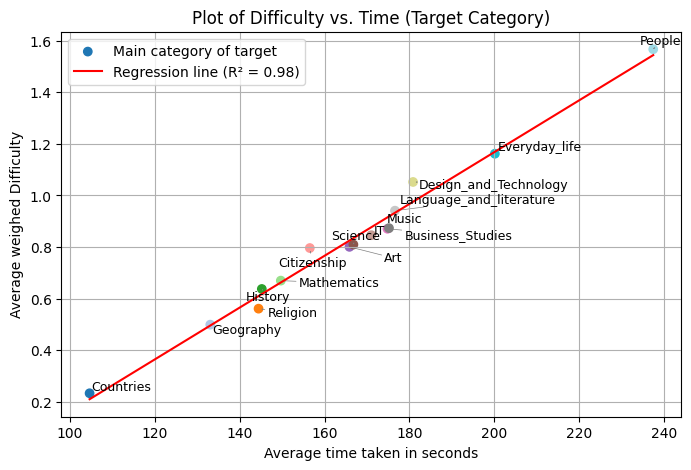

In [12]:
# Spearman correlation
sorted_ATC = ATC.sort_values()
sorted_T_weighed_rating2 = T_weighed_rating.sort_values()

correlation, p_value = spearmanr(sorted_ATC, sorted_T_weighed_rating2)

print("Spearman correlation:", correlation)
print("P-value:", p_value)


# II. Perform linear regression (with log transformation)
slope, intercept, r_value, p_value, std_err = linregress(sorted_ATC, sorted_T_weighed_rating2)

# Create the regression line
x_vals = np.array(sorted_ATC)
y_vals_original = intercept + slope * x_vals

# Use a colormap for each category
categories = sorted_T_weighed_rating2.index
colormap = cm.get_cmap('tab20', len(categories))
colors = {category: colormap(i) for i, category in enumerate(categories)}


# Plot
plt.figure(figsize=(8, 5))
plt.scatter(sorted_ATC, sorted_T_weighed_rating2,
            c=[colors[category] for category in categories], label='Main category of target')
plt.plot(x_vals, y_vals_original, color='red', label=f'Regression line (R² = {r_value**2:.2f})')


# Add labels with adjustText to avoid overlap
texts = [plt.text(x, y, category, fontsize=9) 
         for category, x, y in zip(categories, sorted_ATC, sorted_T_weighed_rating2)]
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))


plt.xlabel('Average time taken in seconds')
plt.ylabel('Average weighed Difficulty')
plt.title('Plot of Difficulty vs. Time (Target Category)')
plt.legend()
plt.grid(True)
plt.show()


Linear log regression analysis:  average time v.s. average wighed difficulty

Spearman correlation: 1.0
P-value: 0.0


C:\Users\Marc\AppData\Local\Temp\ipykernel_12792\3662326133.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab20', len(categories))


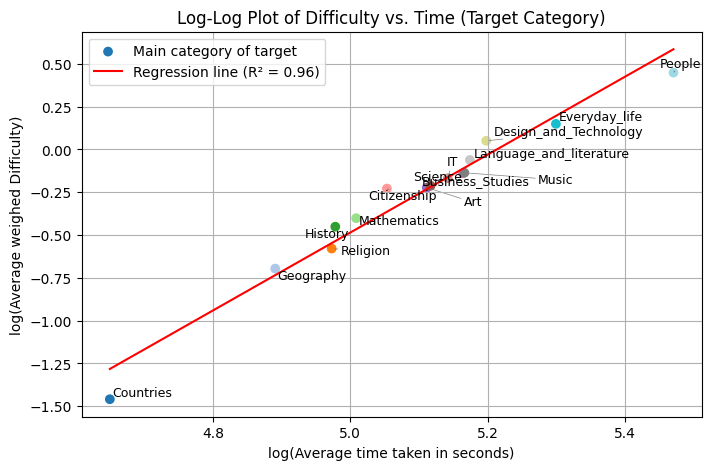

In [13]:
# Spearman correlation
sorted_ATC = ATC.sort_values()
sorted_T_weighed_rating2 = T_weighed_rating.sort_values()

correlation, p_value = spearmanr(sorted_ATC, sorted_T_weighed_rating2)

print("Spearman correlation:", correlation)
print("P-value:", p_value)


# II. Perform linear regression (with log transformation)
slope, intercept, r_value, p_value, std_err = linregress(np.log(sorted_ATC), np.log(sorted_T_weighed_rating2))

# Create the regression line
x_vals = np.array(np.log(sorted_ATC))
y_vals_original = intercept + slope * x_vals

# Use a colormap for each category
categories = sorted_T_weighed_rating2.index
colormap = cm.get_cmap('tab20', len(categories))
colors = {category: colormap(i) for i, category in enumerate(categories)}


# Plot
plt.figure(figsize=(8, 5))
plt.scatter(np.log(sorted_ATC), np.log(sorted_T_weighed_rating2),
            c=[colors[category] for category in categories], label='Main category of target')
plt.plot(x_vals, y_vals_original, color='red', label=f'Regression line (R² = {r_value**2:.2f})')


# Add labels with adjustText to avoid overlap
texts = [plt.text(x, y, category, fontsize=9) 
         for category, x, y in zip(categories, np.log(sorted_ATC), np.log(sorted_T_weighed_rating2))]
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))


plt.xlabel('log(Average time taken in seconds)')
plt.ylabel('log(Average weighed Difficulty)')
plt.title('Log-Log Plot of Difficulty vs. Time (Target Category)')
plt.legend()
plt.grid(True)
plt.show()


### Subcategories

Defininig the variables

In [14]:
# Time taken in a game, and their respective subcategories 
df_timesubcatraw = df_finished [['durationInSec','category2']]

IndexS = df_timesubcatraw['category2'].value_counts().index.astype(str)
n21 = len(IndexS)
n22 = len(df_timesubcatraw)
timesubcat = {IndexS[i]: [0] for i in range(n21)}
df_timesubcat = pd.DataFrame(timesubcat)
df_count2 = pd.DataFrame(timesubcat)

for i in range(n22):
    for j in range(n21):
        a = df_timesubcatraw.loc[i]['category2']
        if a == IndexS[j]:
            df_timesubcat[a] = df_timesubcat[a] + df_timesubcatraw.loc[i]['durationInSec']
            df_count2[a] = df_count2[a] + 1

Calculating the average time taken in a finished game per subcategory

In [15]:
average_time_subcat = df_timesubcat/df_count2
ATS = average_time_subcat.T[0]

Linear regression analysis:  average time v.s. average wighed difficulty

Spearman correlation: 1.0
P-value: 0.0


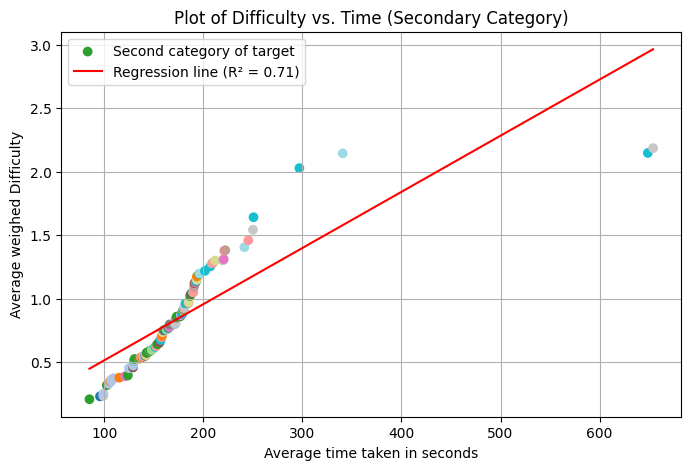

In [16]:
# Spearman correlation
sorted_ATS = ATS.sort_values()
sorted_S_weighed_rating2 = S_weighed_rating.sort_values()

correlation, p_value = spearmanr(sorted_ATS, sorted_S_weighed_rating2)

print("Spearman correlation:", correlation)
print("P-value:", p_value)


# II. Perform linear regression (with log transformation)
slope, intercept, r_value, p_value, std_err = linregress(sorted_ATS, sorted_S_weighed_rating2)

# Create the regression line
x_vals = np.array(sorted_ATS)
y_vals_original = intercept + slope * x_vals

# Creating a color map for the subcategories
sorted_subcategories = sorted_S_weighed_rating2.index
subcategory_to_category = {
    subcat : subcat_to_cat(subcat) for subcat in sorted_subcategories   
}
subcategory_colors = {subcat: colors[category] for subcat, category in subcategory_to_category.items()}

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(sorted_ATS, sorted_S_weighed_rating2,
            c=[subcategory_colors[subcat] for subcat in sorted_subcategories], label='Second category of target')
plt.plot(x_vals, y_vals_original, color='red', label=f'Regression line (R² = {r_value**2:.2f})')

plt.xlabel('Average time taken in seconds')
plt.ylabel('Average weighed Difficulty')
plt.title('Plot of Difficulty vs. Time (Secondary Category)')
plt.legend()
plt.grid(True)
plt.show()

Linear log regression analysis:  average time v.s. average wighed difficulty

Spearman correlation: 1.0
P-value: 0.0


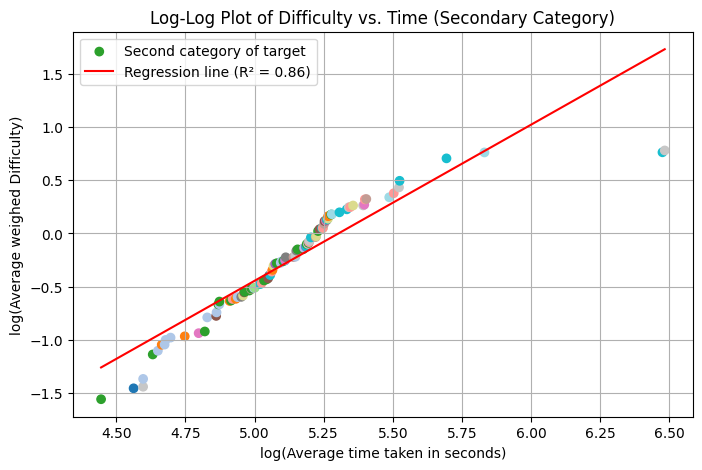

In [17]:
# Spearman correlation
sorted_ATS = ATS.sort_values()
sorted_S_weighed_rating2 = S_weighed_rating.sort_values()

correlation, p_value = spearmanr(np.log(sorted_ATS), np.log(sorted_S_weighed_rating2))

print("Spearman correlation:", correlation)
print("P-value:", p_value)


# II. Perform linear regression (with log transformation)
slope, intercept, r_value, p_value, std_err = linregress(np.log(sorted_ATS), np.log(sorted_S_weighed_rating2))

# Create the regression line
x_vals = np.array(np.log(sorted_ATS))
y_vals_original = intercept + slope * x_vals

# Creating a color map for the subcategories
sorted_subcategories = sorted_S_weighed_rating2.index
subcategory_to_category = {
    subcat : subcat_to_cat(subcat) for subcat in sorted_subcategories   
}
subcategory_colors = {subcat: colors[category] for subcat, category in subcategory_to_category.items()}

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(np.log(sorted_ATS), np.log(sorted_S_weighed_rating2),
            c=[subcategory_colors[subcat] for subcat in sorted_subcategories], label='Second category of target')
plt.plot(x_vals, y_vals_original, color='red', label=f'Regression line (R² = {r_value**2:.2f})')

plt.xlabel('log(Average time taken in seconds)')
plt.ylabel('log(Average weighed Difficulty)')
plt.title('Log-Log Plot of Difficulty vs. Time (Secondary Category)')
plt.legend()
plt.grid(True)
plt.show()